# Optimal Transport via Hypernetworks

This notebook connects **hypernetworks** with **optimal transport** using the **Energy Distance** and **Wasserstein distance**.

## Key Idea

Given source distribution $P$ and target distribution $Q$, optimal transport seeks a map $T$ such that $T(X) \sim Q$ when $X \sim P$, while minimizing transport cost (e.g. $\mathbb{E}[\|X - T(X)\|^2]$ for $W_2$).

**Two-phase approach:**

1. **Phase 1 (Energy Distance Loss)**: Train the hypernetwork with pz frozen so that *every point in $P$ can predict every point in $Q$*. Each $z \sim p(z)$ induces a transport map $f_\phi(z)(\cdot)$. The EDL encourages the *ensemble* of predictions at each $x \in P$ to match the distribution $Q$—so the hypernetwork learns a family of transport maps that collectively cover $Q$.

2. **Phase 2 (L2 + pz optimization)**: Freeze $\phi$ and optimize $p(z)$. For **2D Gaussians**, the $W_2$ optimal transport map has a closed form (affine). We use $(x, T(x))$ pairs with $x \sim P$ and $T$ the analytical optimal map. Minimizing $\mathbb{E}_z[\|f_z(x) - T(x)\|^2]$ selects transport maps that align with the Wasserstein-2 optimum.

Together, EDL provides the expressive family of maps; pz optimization selects the one(s) that minimize the Wasserstein-2 distance.

In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP
from hnet.train.hnet import EnergyDistanceLoss

%load_ext autoreload
%autoreload 2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using cuda


## 2D Two-Gaussian Dataset

Source $P \sim \mathcal{N}(\mu_P, \Sigma_P)$ and target $Q \sim \mathcal{N}(\mu_Q, \Sigma_Q)$. For 2D Gaussians with diagonal covariances, the $W_2$ optimal transport map is $T(x) = \mu_Q + \text{diag}(\sigma_Q / \sigma_P)(x - \mu_P)$.

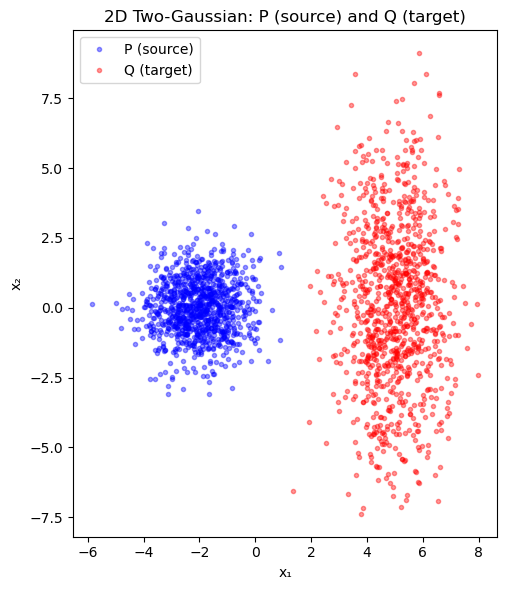

In [40]:
torch.manual_seed(42)
n_samples = 1000

# P: source 2D Gaussian (diagonal cov)
mu_P = torch.tensor([-2.0, 0.0])
sigma_P = torch.tensor([1.0, 1.0])
# Q: target 2D Gaussian
mu_Q = torch.tensor([5.0, 0.0])
sigma_Q = torch.tensor([1, 3])

P = torch.randn(n_samples, 2) * sigma_P + mu_P
Q = torch.randn(n_samples, 2) * sigma_Q + mu_Q

# Optimal W2 map for diagonal Gaussians: T(x) = mu_Q + diag(sigma_Q/sigma_P)(x - mu_P)
def optimal_transport_map(x):
    return mu_Q + (sigma_Q / sigma_P) * (x - mu_P)

# Paired data for Phase 2: (x, T(x)) for x ~ P
Q_paired = optimal_transport_map(P)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.4, label='P (source)')
ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.4, label='Q (target)')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.set_aspect('equal')
ax.set_title('2D Two-Gaussian: P (source) and Q (target)')
plt.tight_layout()
plt.show()

## Phase 1: Train with Energy Distance Loss (pz frozen)

Train the hypernetwork so that for each $x \sim P$, the *ensemble* of predictions $\{f_{\phi}(z)(x) : z \sim p(z)\}$ matches the distribution $Q$. We sample $(x, y)$ with $x \sim P$ and $y \sim Q$; the EDL encourages the predicted distribution at $x$ to be close (in energy distance) to the target $y$. Over training, the ensemble learns to map any $x \in P$ into the support of $Q$.

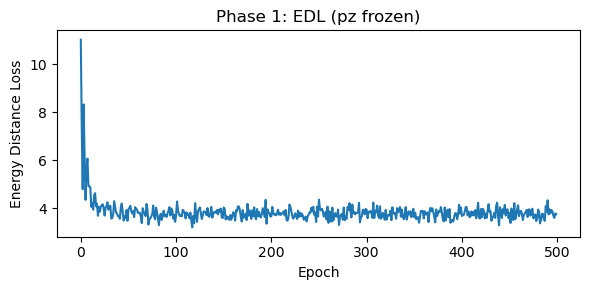

In [41]:
# Build model: maps x (2D) -> y (2D)
mlp = MLP(in_channels=2, out_channels=2, hidden_channels=64, layers=2, nonlin='elu', dropout=0., norm='none')

hnet = HyperNet(
    mlp,
    stochastic_channels=16,
    width=128,
    dropout=0., norm='none', bias=False,
    pz='bernoulli',
    learn_pz=True,  # needed for Phase 2; we freeze the flow in Phase 1
    nvp_kwargs={'hidden_dim': 32, 'num_layers': 4, 'nonlin': 'elu', 'mask_type': 'alternating'},
).to(device)

# Freeze pz for Phase 1
for p in hnet.normalizing_flow.parameters():
    p.requires_grad = False

# Train with Energy Distance Loss: every point in P predicts every point in Q
optim = torch.optim.Adam(filter(lambda p: p.requires_grad, hnet.parameters()), lr=1e-3)
crit_edl = EnergyDistanceLoss()

batch_size, num_epochs, nsamples = 128, 500, 100
losses = []

for epoch in range(num_epochs):
    idx = torch.randperm(n_samples)[:batch_size]
    x_batch = P[idx].to(device)
    y_batch = Q[torch.randperm(n_samples)[:batch_size]].to(device)  # random pairing

    optim.zero_grad()
    yhat = hnet(x_batch, samples=nsamples)  # (nsamples, batch, 1)
    loss = crit_edl(yhat, y_batch)
    loss.backward()
    optim.step()
    losses.append(loss.item())
    print(f'Epoch {epoch}/{num_epochs}  EDL: {loss.item():.4f}', end='\r')

hnet = hnet.cpu()
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Energy Distance Loss')
plt.title('Phase 1: EDL (pz frozen)')
plt.tight_layout()
plt.show()

### Phase 1: Predicted transport

Sample many $z$ and plot the resulting transport maps $x \mapsto f_z(x)$. The ensemble should cover $Q$ when applied to points in $P$.

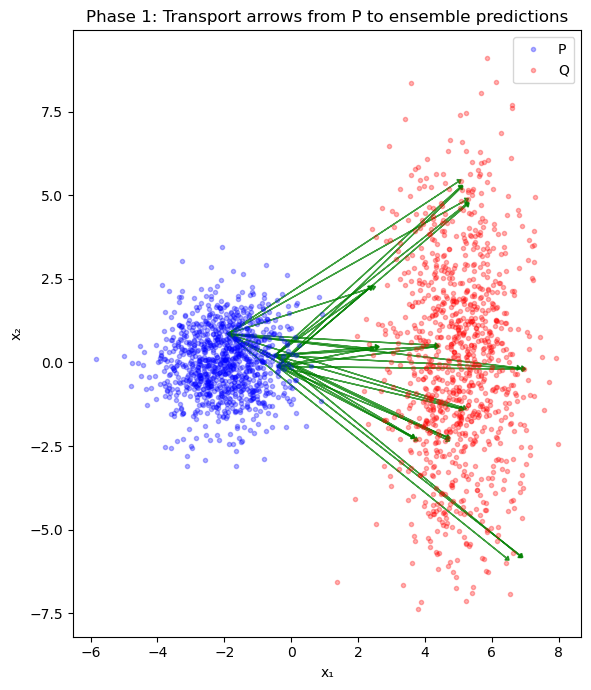

In [42]:
# Plot: P, Q, and predicted transports (arrows from P to predictions)
hnet.eval()
n_show = 3
idx_show = torch.randperm(n_samples)[:n_show]
x_show = P[idx_show]
with torch.no_grad():
    yhat = hnet(x_show, samples=80)  # (80, n_show, 2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.3, label='P')
ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.3, label='Q')
x_np = x_show.cpu().numpy()
for i in range(min(30, n_show)):
    preds = yhat[:, i, :].cpu().numpy()
    for j in range(min(10, len(preds))):
        ax.arrow(x_np[i, 0], x_np[i, 1],
                 preds[j, 0] - x_np[i, 0], preds[j, 1] - x_np[i, 1],
                 head_width=0.15, head_length=0.1, fc='green', ec='green', alpha=0.75)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.set_aspect('equal')
ax.set_title('Phase 1: Transport arrows from P to ensemble predictions')
plt.tight_layout()
plt.show()

## Phase 2: Optimize pz to Minimize L2 (Wasserstein Connection)

Freeze $\phi$ and optimize $p(z)$. Use the **analytical optimal transport pairs** $(x, T(x))$ with $x \sim P$ and $T(x) = \mu_Q + \text{diag}(\sigma_Q/\sigma_P)(x - \mu_P)$. Minimize

$$\mathbb{E}_{z \sim p(z)}\left[\sum_i \|f_z(x_i) - T(x_i)\|^2\right]$$

This expected squared cost is the $W_2$ cost for the coupling induced by our stochastic map. By learning $p(z)$, we concentrate mass on the $z$ that produce transport maps closest to the Wasserstein-2 optimal transport.

Phase 2 epoch 200, L2 loss: 6.7777
Phase 2 epoch 400, L2 loss: 4.5800
Phase 2 epoch 600, L2 loss: 4.1990
Phase 2 epoch 800, L2 loss: 1.9273
Phase 2 epoch 1000, L2 loss: 0.4707


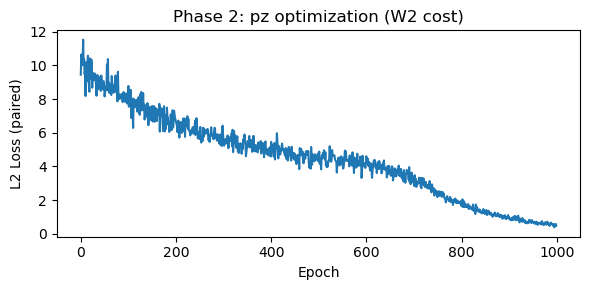

In [43]:
# Freeze phi, unfreeze pz
for p in hnet.f_phi.parameters():
    p.requires_grad = False
for p in hnet.normalizing_flow.parameters():
    p.requires_grad = True

# Paired data: (x, T(x)) for x ~ P (Q_paired already computed in Cell 3)
x_paired = P
y_paired = Q_paired

optim_pz = torch.optim.AdamW(hnet.normalizing_flow.parameters(), lr=1e-4, weight_decay=1e-6)
hnet = hnet.to(device)
x_paired_dev = x_paired.to(device)
y_paired_dev = y_paired.to(device)

losses_pz = []
batch_size_pz = 256
n_epochs_pz = 1000

for epoch in range(n_epochs_pz):
    idx = torch.randperm(n_samples)[:batch_size_pz]
    optim_pz.zero_grad()
    yhat = hnet(x_paired_dev[idx], samples=80)
    # L2: E[||f_z(x) - y||^2] over z
    loss = ((yhat - y_paired_dev[idx].unsqueeze(0)) ** 2).mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(hnet.parameters(), 1.0)
    optim_pz.step()
    losses_pz.append(loss.item())
    if (epoch + 1) % 200 == 0:
        print(f'Phase 2 epoch {epoch+1}, L2 loss: {loss.item():.4f}')

hnet = hnet.cpu()
plt.figure(figsize=(6, 3))
plt.plot(losses_pz)
plt.xlabel('Epoch')
plt.ylabel('L2 Loss (paired)')
plt.title('Phase 2: pz optimization (W2 cost)')
plt.tight_layout()
plt.show()

### Phase 2: Transport after pz optimization

After optimizing $p(z)$, the sampled transport maps should concentrate around the Wasserstein-2 optimal transport (affine map $T(x) = \mu_Q + \text{diag}(\sigma_Q/\sigma_P)(x - \mu_P)$).

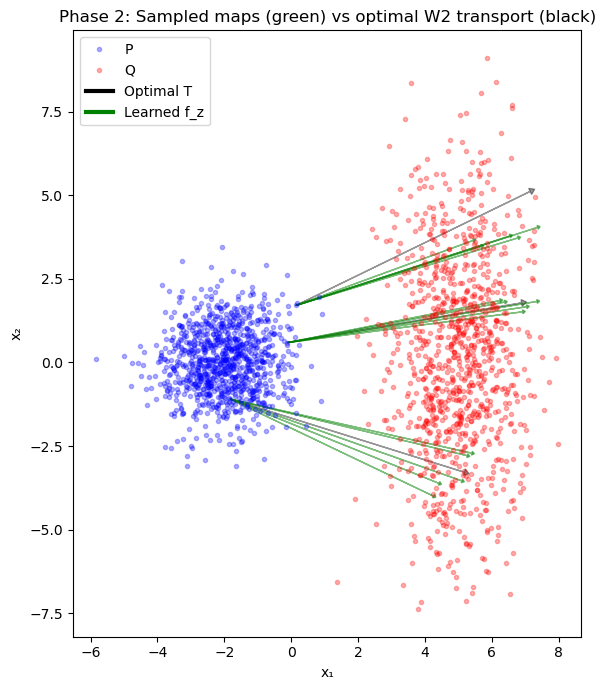

In [44]:
# import Line2D
from matplotlib.lines import Line2D

# Plot: transport maps after pz optimization vs optimal W2 map
hnet.eval()
n_show = 3
x_show = P[torch.randperm(n_samples)[:n_show]]
with torch.no_grad():
    yhat_pz = hnet(x_show, samples=250)  # (50, n_show, 2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.3, label='P')
ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.3, label='Q')
x_np = x_show.numpy()
# Arrows: P -> learned transport (green) and optimal T(x) (black)
for i in range(min(40, n_show)):
    preds = yhat_pz[:, i, :].numpy()
    t_opt = optimal_transport_map(x_show[i:i+1]).squeeze().numpy()
    ax.arrow(x_np[i, 0], x_np[i, 1], t_opt[0] - x_np[i, 0], t_opt[1] - x_np[i, 1],
             head_width=0.2, head_length=0.15, fc='black', ec='black', alpha=0.4)
    for j in range(min(5, len(preds))):
        ax.arrow(x_np[i, 0], x_np[i, 1], preds[j, 0] - x_np[i, 0], preds[j, 1] - x_np[i, 1],
                 head_width=0.12, head_length=0.08, fc='green', ec='green', alpha=0.5)
handles, labels = ax.get_legend_handles_labels()
handles.extend([Line2D([0], [0], color='black', lw=3, label='Optimal T'),
                Line2D([0], [0], color='green', lw=3, label='Learned f_z')])
ax.legend(handles=handles)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_aspect('equal')
ax.set_title('Phase 2: Sampled maps (green) vs optimal W2 transport (black)')
plt.tight_layout()
plt.show()